In [7]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib

In [22]:
clf_model_path =  "../l2d_models/full_dataset_Polypgen_20250421_222611/deferral_classification_model.pkl"
reg_model_path = "../l2d_models/full_dataset_Polypgen_20250421_222611/deferral_regression_model.pkl"
all_feature_csv = "../media/Inference/full_dataset_Polypgen_20250421_222611/model_training_data.csv"
test_feature_csv = "../media/Inference/test_dataset_Polypgen_20250422_114853/model_training_data.csv"

In [23]:
df = pd.read_csv(all_feature_csv)
df.head()

,X,y,y_tmp,mean_future_iou_c,mean_future_iou_u
0,"[0.7922935550783264, -3.984292507171631, 4.252...",0,-0.008446,0.622668,0.631113
1,"[0.8970150011828646, -3.8044822216033936, 4.37...",0,-0.005549,0.575036,0.580584
2,"[0.9517839703412694, -3.81430721282959, 4.4264...",0,0.051758,0.551534,0.499775
3,"[0.9403030066834425, -4.428088188171387, 5.013...",0,0.014919,0.440848,0.425929
4,"[0.9607740533662056, -4.056418418884277, 5.292...",0,0.395548,0.735721,0.340173


In [24]:
df["X"]

0       [0.7922935550783264, -3.984292507171631, 4.252...
1       [0.8970150011828646, -3.8044822216033936, 4.37...
2       [0.9517839703412694, -3.81430721282959, 4.4264...
3       [0.9403030066834425, -4.428088188171387, 5.013...
4       [0.9607740533662056, -4.056418418884277, 5.292...
                              ...                        
1379    [0.1111412411654255, -11.259041786193848, 3.62...
1380                [0.0, -1024.0, 0.0, 0.0, -0.21582031]
1381                  [0.0, -1024.0, 0.0, 0.0, -1.046875]
1382                [0.0, -1024.0, 0.0, 0.0, -0.98828125]
1383                [0.0, -1024.0, 0.0, 0.0, -0.55078125]
Name: X, Length: 1384, dtype: object

In [41]:
df

,y,y_tmp,mean_future_iou_c,mean_future_iou_u,X_0,X_1,X_2,X_3,X_4
0,0,-0.008446,0.622668,0.631113,0.792294,-3.984293,4.252599,104284.0,8.500000
1,0,-0.005549,0.575036,0.580584,0.897015,-3.804482,4.377153,112165.0,7.625000
2,0,0.051758,0.551534,0.499775,0.951784,-3.814307,4.426447,107990.0,7.250000
3,0,0.014919,0.440848,0.425929,0.940303,-4.428088,5.013247,97682.0,7.718750
4,0,0.395548,0.735721,0.340173,0.960774,-4.056418,5.292379,104888.0,7.062500
...,...,...,...,...,...,...,...,...,...
1379,0,0.040558,0.160162,0.119603,0.111141,-11.259042,3.627240,16973.0,0.476562
1380,0,0.185872,0.185872,0.000000,0.000000,-1024.000000,0.000000,0.0,-0.215820
1381,0,0.314015,0.314015,0.000000,0.000000,-1024.000000,0.000000,0.0,-1.046875
1382,0,0.478010,0.478010,0.000000,0.000000,-1024.000000,0.000000,0.0,-0.988281


In [ ]:
import ast
df['X'] = df['X'].apply(ast.literal_eval)
X_expanded = pd.DataFrame(df['X'].tolist(), index=df.index)
X_expanded.columns = [f'X_{i}' for i in range(X_expanded.shape[1])]
# Concatenate the new columns with the original DataFrame
df = pd.concat([df, X_expanded], axis=1)
df.drop(columns=['X'], inplace=True)
# df.drop(columns=['X'], inplace=True)
# Extract the dataframe consisting of X_0, X_1, X_2, X_3, and X_4
X_df = df[['X_4']]


,X_4
0,8.500000
1,7.625000
2,7.250000
3,7.718750
4,7.062500
...,...
1379,0.476562
1380,-0.215820
1381,-1.046875
1382,-0.988281


In [27]:
# # Standardize X_df values
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_df)

# # Convert df['y'] to classification labels (assuming binary classification)
# y_class = np.where(df['y'] > 0, 1, 0)

# # Train-test split with a fixed split (using a fixed random state)
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# # # Train a logistic regression model
# # clf = LogisticRegression()
# # clf.fit(X_train, y_train)

# # # Predict on the test set and get probabilities
# # y_pred, y_pred_proba = clf.predict(X_test), clf.predict_proba(X_test)

# # # Evaluate the model
# # accuracy = accuracy_score(y_test, y_pred)
# # print(f"Accuracy: {accuracy}")




Accuracy: 0.8989169675090253


In [32]:
# Standardize X_df values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# # Convert df['y'] to classification labels (assuming binary classification)
# y_class = np.where(df['y'] > 0, 1, 0)

# Train-test split with a fixed split (using a fixed random state)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['y_tmp'], test_size=0.2, random_state=42)

# # Train a logistic regression model
# clf = LogisticRegression()
# clf.fit(X_train, y_train)

# # Predict on the test set and get probabilities
# y_pred, y_pred_proba = clf.predict(X_test), clf.predict_proba(X_test)

# # Evaluate the model
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy}")




In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Get predictions
y_pred_reg = reg.predict(X_test)

# Get accuracy metrics
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)



MSE: 0.10260995967481382
R2 Score: 0.25387688553303556


In [34]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))

0.20533972892506802


In [35]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))  

0.1886440706415783


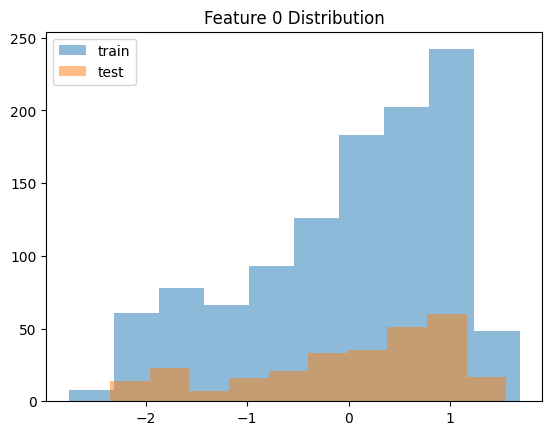

In [36]:
import matplotlib.pyplot as plt
plt.hist(X_train[:, 0], alpha=0.5, label='train')
plt.hist(X_test[:, 0], alpha=0.5, label='test')
plt.legend()
plt.title("Feature 0 Distribution")
plt.show()

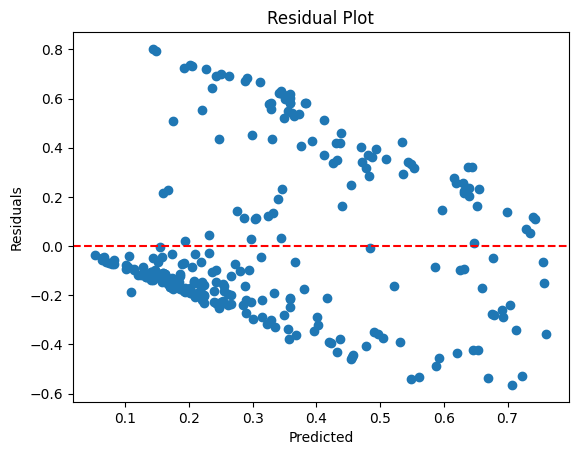

In [37]:
residuals = y_test - y_pred_reg
plt.scatter(y_pred_reg, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [38]:
print("Correlation:", np.corrcoef(y_test, y_pred_reg)[0, 1])

Correlation: 0.5046398291538922


In [39]:
y_pred_flipped = -y_pred
r2 = r2_score(y_test, y_pred_flipped)
print("Flipped R²:", r2)

Flipped R²: -0.8442843179358119


In [43]:
X_df_sigmoid = 1 / (1 + np.exp(-X_df))
X_df_sigmoid

,X_4
0,0.999797
1,0.999512
2,0.999290
3,0.999556
4,0.999144
...,...
1379,0.616936
1380,0.446253
1381,0.259826
1382,0.271252


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df_sigmoid)

# # Convert df['y'] to classification labels (assuming binary classification)
# y_class = np.where(df['y'] > 0, 1, 0)

# Train-test split with a fixed split (using a fixed random state)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['y_tmp'], test_size=0.2, random_state=42)



In [45]:
# Train regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Get predictions
y_pred_reg = reg.predict(X_test)

# Get accuracy metrics
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.12508070978034655
R2 Score: 0.0904819664990284


In [46]:
model = XGBRegressor()
model.fit(X_train, y_train)
print(model.score(X_test, X_train))

0.20533972892506802


In [47]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.12143024130410424
R2 Score: 0.11702616276797917


In [48]:
X_df = df[['X_0','X_1','X_2','X_3','X_4']]

In [49]:
# Standardize X_df values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# # Convert df['y'] to classification labels (assuming binary classification)
# y_class = np.where(df['y'] > 0, 1, 0)

# Train-test split with a fixed split (using a fixed random state)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['y_tmp'], test_size=0.2, random_state=42)



In [50]:
# Train regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Get predictions
y_pred_reg = reg.predict(X_test)

# Get accuracy metrics
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.08997034432938764
R2 Score: 0.3457852070749321


In [51]:
model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.0653645991956746
R2 Score: 0.5247046341084136


In [52]:
model = XGBRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.05145280770514929
R2 Score: 0.6258635199282816


In [65]:
from sklearn.ensemble import RandomForestRegressor
import pickle

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(model, file)

MSE: 0.048197315533206456
R2 Score: 0.6495356660450002


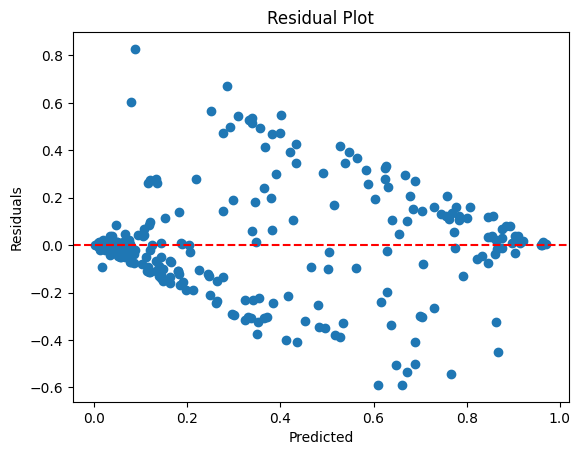

In [66]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

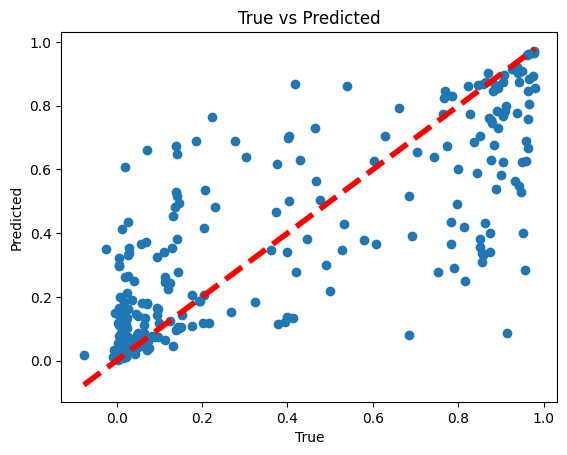

In [67]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.show()